# COMP662 Assignment 1 — Synthetic Dataset Generation

**Student ID:** 1173808  
**Dataset:** `train.csv` (Dried Bean Classification)  

## ENV & Libs Setup

In [1]:
from pathlib import Path
import random
import time

setup_started = time.perf_counter()

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F

# set device to GPU if available, otherwise mps then CPU
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
# define & set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
else:
    torch.set_num_threads(1)

ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
KAGGLE_ROOT = Path("/kaggle")
kaggle_data = (
    sorted((KAGGLE_ROOT / "input").rglob("train.csv")) if KAGGLE_ROOT.is_dir() else []
)
DATA_PATH = kaggle_data[0] if kaggle_data else ROOT / "data" / "train.csv"
OUTPUT_DATA = ROOT / "data"
FIGURES = ROOT / "figures"
MODELS = ROOT / "models"
OUTPUT_DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

if DEVICE.type == "cuda":
    RUNTIME_DEVICE = f"{torch.cuda.get_device_name(0)} x{torch.cuda.device_count()}"
elif DEVICE.type == "mps":
    RUNTIME_DEVICE = "Apple Silicon MPS"
else:
    RUNTIME_DEVICE = "CPU"

def format_decimal(value):
    return np.format_float_positional(float(value), unique=True, trim="-")


def log_cell(name, started, configuration):
    print(
        f"{name}: device={RUNTIME_DEVICE}; configuration={configuration}; elapsed_seconds={format_decimal(time.perf_counter() - started)}"
    )


assert DATA_PATH.exists(), f"Missing training data: {DATA_PATH}"
data_location = "Kaggle attached train.csv" if kaggle_data else "data/train.csv"
# log the environment setup information
log_cell(
    "Environment setup",
    setup_started,
    f"torch={torch.__version__}, seed={SEED}, data={data_location}",
)


Environment setup: device=Apple Silicon MPS; configuration=torch=2.12.0, seed=42, data=data/train.csv; elapsed_seconds=2.7798666250891984


Expected output

**Environment setup: device=Apple Silicon MPS; configuration=torch=2.12.0, seed=42, data=data/train.csv**


## Task 1 — Data understanding and concise exploratory data analysis

### 1.1 Class distribution: counts and percentages


In [2]:
# Load the released training data and separate the target from its ten numerical features.
cell_started = time.perf_counter()
data = pd.read_csv(DATA_PATH)
target = "Class"
features = [column for column in data.columns if column != target]

# Validate data integrity: correct shape, target range, and missing values detection.
assert data.shape == (12_111, 11), f"Unexpected shape: {data.shape}"
assert data[target].between(0, 4).all(), "Target values out of range"
assert data[features].isna().sum().sum() == 0, "Missing values detected"

# Count each bean class and calculate its percentage of the full dataset.
class_distribution = (
    data[target]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
    .assign(percentage=lambda frame: 100 * frame["count"] / len(data))
)
display(class_distribution)
log_cell("Data loading", cell_started, f"shape={data.shape}, features={len(features)}")

       count  percentage
Class                   
0       3246   26.802081
1       3174   26.207580
2       2336   19.288250
3       1727   14.259764
4       1628   13.442325
Data loading: device=Apple Silicon MPS; configuration=shape=(12111, 11), features=10; elapsed_seconds=0.01264241710305214


Expected output

**Dataset shape: (12111, 11)** with class distribution as shown above

to confirm 12,111 observations, 10 features, 5 classes, no missing values

| Class | Count | Percentage |
| :---: | ----: | ---------: |
|   0   | 3,246 |     26.80% |
|   1   | 3,174 |     26.21% |
|   2   | 2,336 |     19.29% |
|   3   | 1,727 |     14.26% |
|   4   | 1,628 |     13.44% |

**Interpretation:**

Classes 0 and 1 are the largest groups (26.8% and 26.2%), and class 4 is the smallest (13.4%). This is a imbalance issue across different classes, the ratio between largest and smallest like 3246/1628 > 1.993, so consider to use macro-F1 as primary metrics to measure the performance on minor class types.


### 1.2 Visual analysis of representative features

`Area`, `Perimeter`, `MajorAxisLength`, and `Eccentricity` are selected because of there are representing size and shape features. following code will generate plots to compares their distributions across all five classes.


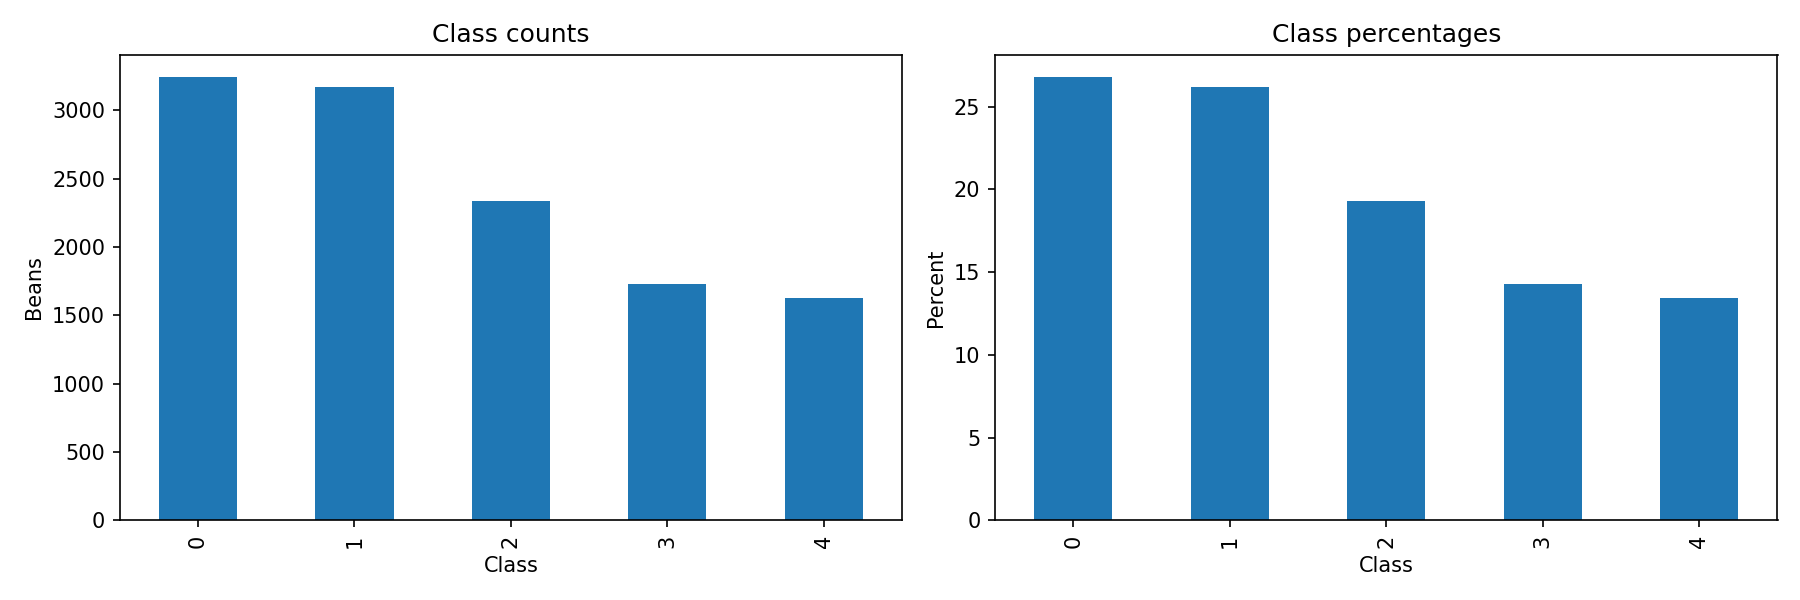

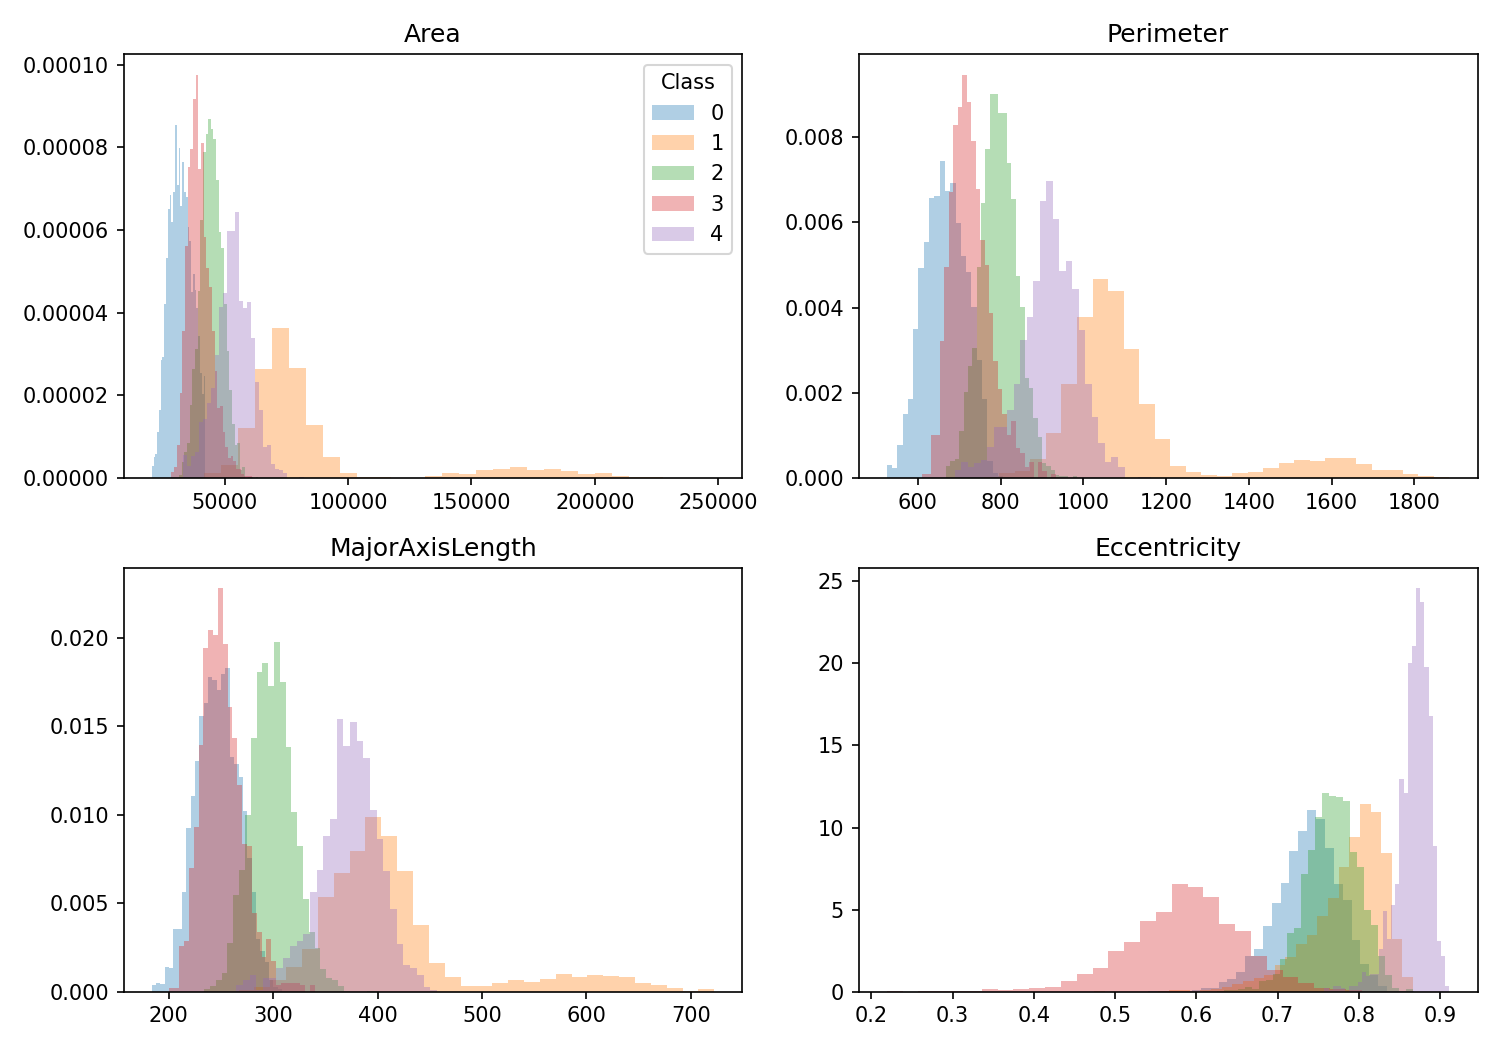

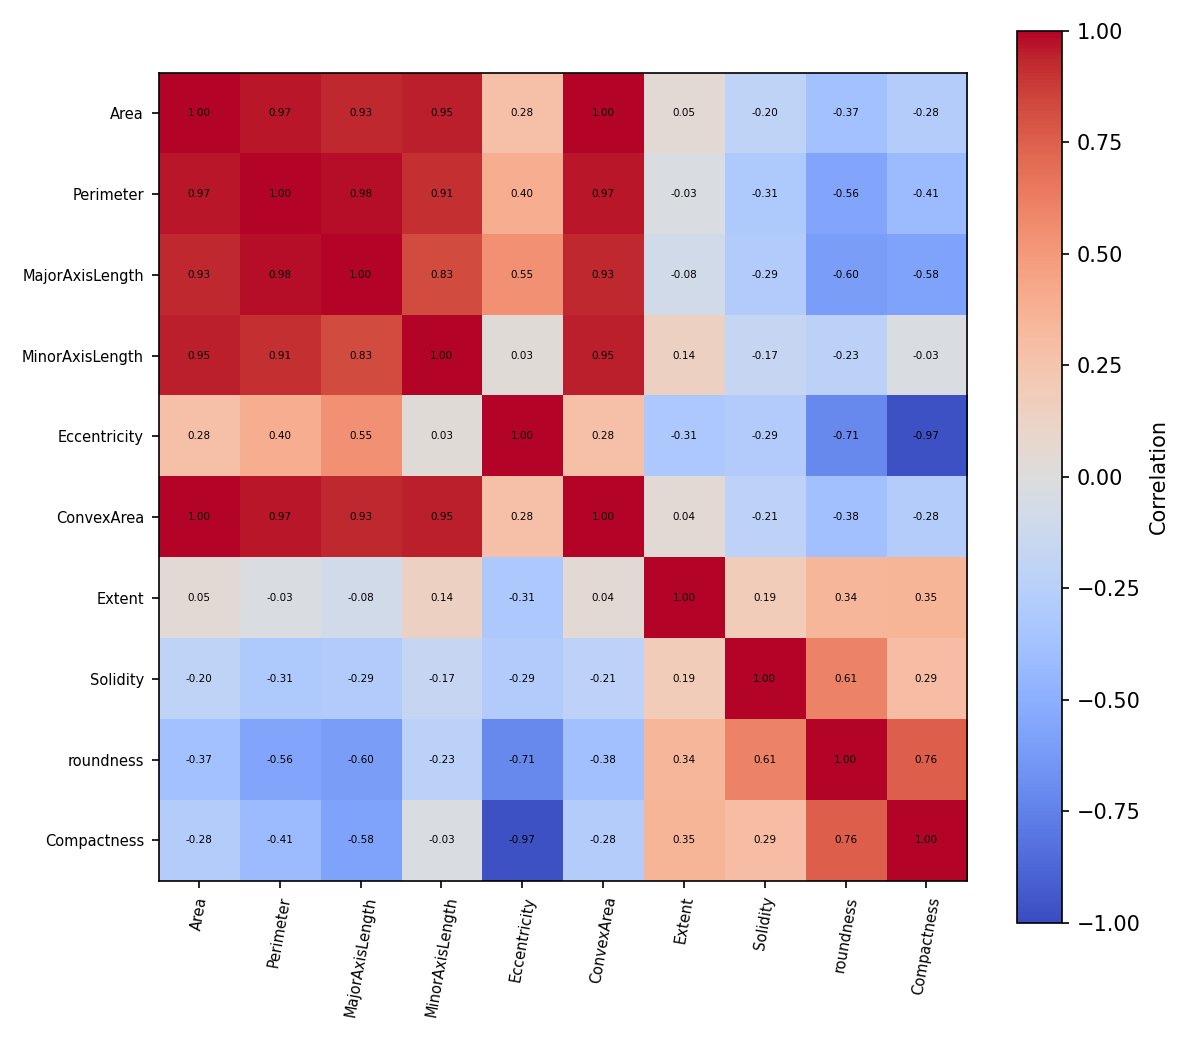

correlation matrix:                      Area  Perimeter  ...  roundness  Compactness
Area             1.000000   0.966700  ...  -0.374140    -0.278756
Perimeter        0.966700   1.000000  ...  -0.562084    -0.414073
MajorAxisLength  0.932570   0.976960  ...  -0.604575    -0.575334
MinorAxisLength  0.951201   0.914011  ...  -0.231772    -0.025491
Eccentricity     0.275380   0.395834  ...  -0.711333    -0.970152
ConvexArea       0.999937   0.967699  ...  -0.378752    -0.280534
Extent           0.045905  -0.027982  ...   0.338394     0.347879
Solidity        -0.204871  -0.311291  ...   0.607113     0.293378
roundness       -0.374140  -0.562084  ...   1.000000     0.756709
Compactness     -0.278756  -0.414073  ...   0.756709     1.000000

[10 rows x 10 columns]
EDA figures: device=Apple Silicon MPS; configuration=class_distribution, feature_distributions, correlation_heatmap; elapsed_seconds=0.919986458029598


In [3]:
# Generate and display EDA figures: class distribution, feature distributions, and correlation heatmap.
cell_started = time.perf_counter()

# Class distribution bar charts by count and percentage.
counts = data[target].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot.bar(ax=axes[0], title="Class counts", xlabel="Class", ylabel="Beans")
(counts / len(data) * 100).plot.bar(ax=axes[1], title="Class percentages", xlabel="Class", ylabel="Percent")
fig.tight_layout()
fig.savefig(FIGURES / "class_distribution.png", dpi=150)
plt.close(fig)

# Feature distribution histograms for four representative features.
chosen_features = ["Area", "Perimeter", "MajorAxisLength", "Eccentricity"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for feature, ax in zip(chosen_features, axes.ravel()):
    for label, group in data.groupby(target):
        ax.hist(group[feature], bins=30, alpha=0.35, label=str(label), density=True)
    ax.set_title(feature)
axes[0, 0].legend(title="Class")
fig.tight_layout()
fig.savefig(FIGURES / "feature_distributions.png", dpi=150)
plt.close(fig)

# Correlation heatmap for all ten numerical features.
fig, ax = plt.subplots(figsize=(8, 7))
corr = data[features].corr()
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(features)), features, rotation=80, fontsize=7)
ax.set_yticks(range(len(features)), features, fontsize=7)
for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=5)
fig.colorbar(image, ax=ax, label="Correlation")
fig.tight_layout()
fig.savefig(FIGURES / "real_correlation.png", dpi=150)
plt.close(fig)

display(Image(filename=FIGURES / "class_distribution.png"))
display(Image(filename=FIGURES / "feature_distributions.png"))
display(Image(filename=FIGURES / "real_correlation.png"))
print("correlation matrix:",data[features].corr())
log_cell("EDA figures", cell_started, "class_distribution, feature_distributions, correlation_heatmap")

Expected output

Three figures saved: `class_distribution.png`, `feature_distributions.png`, `real_correlation.png`

to confirm EDA visualisations generated

### 1.3 Classes distribution and Continuous-feature correlation analysis

**Key Observations:**

1. **Class Distribution & Separability:**
   - **Class 2** stands out distinctly in physical size metrics (`Area`, `Perimeter`, `MajorAxisLength`, `ConvexArea`), representing substantially larger bean phenotypes.
   - **Class 4** is clearly separated along shape dimensions, displaying high `Eccentricity` and low `Compactness` (more elongated morphology).
   - **Classes 0 and 1** exhibit substantial overlap across multiple size and geometric dimensions, forming the primary classification challenge.

2. **Correlation Structure:**
   - **Collinear Size Features:** `Area` and `ConvexArea` exhibit near-perfect collinearity (r > 0.999), and `Perimeter` correlates strongly with `MajorAxisLength` (r = 0.977).
   - **Inverse Shape Relationships:** `Eccentricity` and `Compactness` show a strong negative correlation (r = -0.970), directly reflecting the mathematical formulation of elongation.

3. **Physical & Mathematical Domain Constraints:**
   Dried bean morphology is governed by strict geometric and mathematical laws that establish fundamental consistency benchmarks for data generation and quality assurance:
   - **Positivity of Physical Measures:** All dimensions and ratios must be strictly positive: `Area > 0`, `Perimeter > 0`, `MajorAxisLength > 0`, `MinorAxisLength > 0`, `ConvexArea > 0`, `Extent > 0`, and `Compactness > 0`.
   - **Convex Hull & Solidity Inequality:** The convex bounding polygon must enclose the bean region (`ConvexArea >= Area`), guaranteeing `Solidity = Area / ConvexArea <= 1.0` and `Solidity > 0`.
   - **Isoperimetric Inequality (`roundness`):** By planar geometry, a circle maximizes area per perimeter, mathematically bounding `roundness = (4 * pi * Area) / (Perimeter^2) <= 1.0` and `roundness > 0`.
   - **Ellipse `Eccentricity`:** Derived from the equivalent ellipse moments, restricting `0 <= Eccentricity < 1.0`.


### 1.4 EDA effects on preprocessing, model, metrics, and cross-validation

| Decision                | Evidence from EDA                                                           | Action                                                | Reason / Trade-off                                                                                                                                 |
| :---------------------- | :-------------------------------------------------------------------------- | :---------------------------------------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Missing Values**      | Zero missing values across all 11 columns                                   | Pass through without imputation                       | Imputation is unnecessary.                                                                                                                         |
| **Feature Scaling**     | Features have vast scale range (`Area`: 32k–86k vs `Eccentricity`: 0.5–0.9) | Fit `StandardScaler` on training split only           | Required for neural generative models and not harmful for other model like random forest, will apply to all of them to ensures a fair comparision. |
| **Outlier Handling**    | Heavy-tailed distributions in size metrics with outlier                     | Retain all valid data                                 | Extreme values represent some edge case infomation which model should aware                                                                        |
| **Class Imbalance**     | ~2:1 ratio between majority (Class 0: 26.8%) and minority (Class 4: 13.4%)  | Adopt **Macro-F1** as primary metric                  | Gives equal weight to each class, ensuring minority class degradation is penalized.                                                                |
| **Validation Strategy** | Imbalanced class proportions across classes                                 | Use **Stratified 5-Fold CV** & Stratified 80/20 split | Preserves class distribution proportions across every fold and test partition.                                                                     |


## Task 2 — Baseline classifier development

### 2.1 Necessary preprocessing and justification

1. **Data Spliting (Stratified 80/20 Split):** A 20% test dataset (`test_size=0.20`, `stratify=y`, `random_state=42`) was held out prior to any fitting to prevent data leakage.
2. **Feature Standardization (`StandardScaler`):** Fitted on the training dataset only (`x_train`) to prevent data leakage, applying to all kind of models to guarantee a fair comparison of metrcis between sensitive model like CVAE or others like Random Forest.
3. **Stratified 5-Fold Cross-Validation:** Used across all training folds to provide low-variance, leak-free validation estimates while maintaining exact class proportions.

**Actions WON'T do:**

1. **No Missing Value Imputation:** Complete dataset verification in EDA confirmed 0 missing values.
2. **No Categorical Encoding:** All 10 input variables are continuous physical/morphological measurements.
3. **No Outlier Clipping/Removal:** Outlier bean measurements represent genuine biological info.
4. **No feature Reduction:** All 10 features are providing valuable biological info for data training, so no feature reduction to maximise the info for training even some of them are showing high correlation.


### 2.2 Baseline classifier selection and justification

**Selected baseline model:** `RandomForestClassifier(n_estimators=100, min_samples_leaf=2, random_state=42)`

**Justification:**

1. **Non-linear Decision Boundaries & Interactions:** Random Forest can naturally capture complex non-linear relationship among bean attributes without requiring more feature engineering.
2. **Robustness to Multicollinearity:** Tree split criteria handle highly correlated feature clusters (such as `Area`, `Perimeter`, and `ConvexArea`).
3. **Intentional Absence of Class Weighting (`class_weight=None`):** Internal weighting algorithms (such as `class_weight="balanced"`) adjust sample weights inside the loss function to compensate for class imbalance. Leaving the baseline uncompensated ensures its Macro-F1 directly reflects imbalance penalties, allowing any performance change observed during synthetic data augmentation in Task 5.


### 2.3 Primary metric, secondary metric, and cross-validation strategy

- **Primary Metric — Macro-F1:** Calculates the unweighted mean of F1-scores across all 5 classes. Treats each class with equal importance regardless of frequency, preventing majority-class dominance from masking poor minority-class performance.
- **Secondary Metric — Accuracy:** overall correctness across the entire dataset as a global baseline benchmark
- **Cross-Validation Strategy — Stratified 5-Fold CV:** Evaluates model variance and generalization within the training set, ensuring each validation fold preserves exact class proportions without test set leakage.
- **Held-out Test Evaluation:** An untouched 20% stratified test partition (2,423 instances) is reserved exclusively for final comparative evaluation.


### 2.4 Baseline training, evaluation, held-out test set, and leakage prevention

In [4]:
cell_started = time.perf_counter()

# create RF baseline without class weighting
def create_classifier():
    return RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=2,
        n_jobs=1,
        random_state=SEED,
    )

# Split data: 80% train, 20% test (stratified).
x_train, x_test, y_train, y_test = train_test_split(
    data[features],
    data[target],
    test_size=0.20,
    stratify=data[target],
    random_state=SEED,
)
print(f"Train / test: {len(x_train):,} / {len(x_test):,}")

# Fit scaler on training data only to prevent leakage.
scaler = StandardScaler().fit(x_train)
x_train_scaled = pd.DataFrame(
    scaler.transform(x_train), columns=features, index=x_train.index
)
x_test_scaled = pd.DataFrame(
    scaler.transform(x_test), columns=features, index=x_test.index
)

# Five-fold stratified cross-validation on training data.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
baseline_model = create_classifier()
cv_macro_f1 = cross_val_score(
    baseline_model, x_train_scaled, y_train, scoring="f1_macro", cv=cv, n_jobs=1
)

# Fit on all training rows, evaluate on held-out test rows.
baseline_model.fit(x_train_scaled, y_train)
baseline_prediction = baseline_model.predict(x_test_scaled)
baseline_result = {
    "macro_f1": f1_score(y_test, baseline_prediction, average="macro"),
    "accuracy": accuracy_score(y_test, baseline_prediction),
    "prediction": baseline_prediction,
}

print("CV macro-F1 mean:", format_decimal(cv_macro_f1.mean()))
print("CV macro-F1 std:", format_decimal(cv_macro_f1.std()))
print("Held-out macro-F1:", format_decimal(baseline_result["macro_f1"]))
print("Held-out accuracy:", format_decimal(baseline_result["accuracy"]))
log_cell("Baseline training", cell_started, "n_estimators=100, cv=5, test_size=0.2")

Train / test: 9,688 / 2,423
CV macro-F1 mean: 0.9295822586596731
CV macro-F1 std: 0.0029312909233926037
Held-out macro-F1: 0.9334348688275712
Held-out accuracy: 0.9335534461411473
Baseline training: device=Apple Silicon MPS; configuration=n_estimators=100, cv=5, test_size=0.2; elapsed_seconds=6.561598374973983


Expected output

**Train / test: 9,688 / 2,423**
**CV macro-F1 mean: 0.9295822586596731**
**Held-out macro-F1: 0.9334348688275712**
**Held-out accuracy: 0.9335534461411473**

to confirm baseline RF trained and evaluated


**Baseline Model metrics (Apple Silicon MPS):**

| Model | CV Macro-F1 Mean | CV Macro-F1 Std | Held-out Macro-F1 | Held-out Accuracy |
| :--- | :---: | :---: | :---: | :---: |
| **Random Forest** | 0.9295822586596731 | 0.0029312909233926037 | 0.9334348688275712 | 0.9335534461411473 |


## Task 3 — Generative model development and justification

### 3.1 Selected generative model and justification

Selected Model: Conditional Variational Autoencoder (CVAE)

Justification:

1. Can generate samples of a chosen classes. CVAE feeds the class label into both the encoder and decoder. So it can generate data for only the minority classes (Classes 1, 2, 3, 4) to make the dataset fully balanced in classes.

2. Suits continuous table data. The bean features are physical data in sizes and shapes, all continuous numbers. CVAE handles this type of data well because it learns Gaussian latent variables and optimise with MSE.


### 3.2 Model architecture, components, and their roles

| Component | Architecture | Role |
| :--- | :--- | :--- |
| **Class Embedding** | `nn.Embedding(num_embeddings=5, embedding_dim=4)` | Maps discrete class integers (0-4) into a dense 4D continuous vector conditioning signal. |
| **Encoder** | `Linear(14, 64) -> ReLU -> Linear(64, 32) -> ReLU` | Compresses concatenated feature-embedding vectors (10 features + 4D embedding) into hidden features. |
| **Latent Heads** | `Linear(32, 8)` for mean, `Linear(32, 8)` for log-variance | Parameterizes the mean and log-variance of the 8-dimensional class-conditional Gaussian distribution. |
| **Reparameterization** | `z = mean + eps * exp(0.5 * log_var)` | Enables differentiable backpropagation through stochastic sampling during training. |
| **Decoder** | `Linear(12, 32) -> ReLU -> Linear(32, 64) -> ReLU -> Linear(64, 10)` | Reconstructs 10 continuous standardized features from concatenated latent code (8D) and class embedding (4D). |


### 3.3 Tabular-data representation and generation

- **Input Representation:** Each observation is represented as a 10-dimensional standardized feature vector concatenated with a 4D learnable class embedding vector (14 dimensions total).
- **Generation Mechanism:** To generate synthetic samples for a class, the class embedding is retrieved and concatenated with a random 8D latent vector sampled from standard Gaussian noise. The concatenated 12D vector is passed through the decoder network to produce standardized feature coordinates, which are subsequently mapped back to original physical units via `scaler.inverse_transform`.


### 3.4 Generative-model preprocessing or transformations

1. **Feature Standardization:** `StandardScaler` is fitted strictly on `x_train` only (to prevent data leakage) to transform all 10 continuous features to zero mean and unit variance (mean = 0, std = 1). This ensures stable gradient updates during neural network training.
2. **Class Label Encoding & Embedding:** Discrete integer class labels (0 to 4) are passed into an `nn.Embedding(5, 4)` layer, converting categorical conditions into dense 4-dimensional continuous vectors.
3. **Inverse Transformation:** Synthetic samples output by the CVAE decoder in standardized space are mapped back to their original physical units via `scaler.inverse_transform` for quality evaluation and downstream classification.


### 3.5 Assumptions, limitations, and potential risks

1. **Gaussian Prior Assumption:** Assumes latent features follow standard normal distributions; multimodal or highly skewed sub-cluster structures within a single class may be oversimplified.
2. **Violation of Physical Domain Constraints:** Unconstrained decoder linear outputs can generate unrealistic rows that violate the physical and geometric rules defined in **Task 1.3** (e.g., `Area > ConvexArea` or `Solidity > 1.0`).
3. **Sample Diversity vs. Memorization Risk:** Overfitting on small minority classes risks memorizing training instances rather than discovering general underlying manifolds.
4. **Boundary Blur & Overlap:** CVAE reconstructions can smooth out decision boundaries between naturally overlapping classes (e.g., Classes 0 and 1), introducing label noise during downstream classifier augmentation.


## Task 4 — Data synthesis and quality assurance

### 4.1 Generative-model training procedure

In [5]:
cell_started = time.perf_counter()

# define the Conditional Variational Autoencoder (CVAE) architecture for table data generation
class ConditionalVAE(nn.Module):

    def __init__(self, n_features, n_classes):
        super().__init__()
        # Embedding class label to 4d vector.
        self.embedding = nn.Embedding(n_classes, 4)
        # Encoder: input (features + embedding) → hidden representation.
        self.encoder = nn.Sequential(
            nn.Linear(n_features + 4, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        # Latent space: mean and log variance heads.
        self.mean = nn.Linear(32, 8)
        self.log_var = nn.Linear(32, 8)
        # Decoder: (latent sample + embedding) → reconstructed features.
        self.decoder = nn.Sequential(
            nn.Linear(12, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, n_features),
        )

    def forward(self, x, labels):
        # forward pass: encode, sample, decode.
        embedded = self.embedding(labels)
        hidden = self.encoder(torch.cat([x, embedded], dim=1))
        mean, log_var = self.mean(hidden), self.log_var(hidden)
        # Reparameterization trick.
        latent = mean + torch.randn_like(mean) * torch.exp(0.5 * log_var)
        return self.decoder(torch.cat([latent, embedded], dim=1)), mean, log_var

    def sample(self, labels):
        # Generate synthetic samples for given class labels.
        latent = torch.randn(len(labels), 8, device=labels.device)
        return self.decoder(torch.cat([latent, self.embedding(labels)], dim=1))


def train_vae(x_train, y_train, n_classes):
    # Fit scaler on training data only to prevent leakage.
    scaler = StandardScaler().fit(x_train)
    x_scaled = torch.tensor(scaler.transform(x_train), dtype=torch.float32, device=DEVICE)
    labels = torch.tensor(y_train.to_numpy(), dtype=torch.long, device=DEVICE)

    # Initialize model and optimizer.
    model = ConditionalVAE(x_train.shape[1], n_classes).to(DEVICE)
    if DEVICE.type == "cuda" and torch.cuda.device_count() > 1:
        # use DataParallel for multi-GPU training
        model = nn.DataParallel(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Training loop: 100 epochs, batch size 256.
    model.train()
    for _ in range(100):
        for batch in torch.randperm(len(x_scaled)).split(256):
            reconstruction, mean, log_var = model(x_scaled[batch], labels[batch])
            reconstruction_loss = F.mse_loss(reconstruction, x_scaled[batch])
            # calculate KL divergence loss
            kl_loss = -0.5 * torch.mean(1 + log_var - mean.pow(2) - log_var.exp())
            # reset gradients
            optimizer.zero_grad()
            # compute total loss and backpropagate
            (reconstruction_loss + 0.02 * kl_loss).backward()
            optimizer.step()

    return model.eval(), scaler


# Train the CVAE.
vae_model, vae_scaler = train_vae(x_train, y_train, n_classes=data[target].nunique())
print("CVAE training completed with 100 epochs and batch size 256.")
log_cell("CVAE training", cell_started, "epochs=100, batch_size=256, latent_dim=8")

CVAE training completed with 100 epochs and batch size 256.
CVAE training: device=Apple Silicon MPS; configuration=epochs=100, batch_size=256, latent_dim=8; elapsed_seconds=24.652714542113245


Expected output

**CVAE training completed with 100 epochs and batch size 256.**

to confirm VAE training converged

### 4.2 Generation strategy and justification

**Strategy:** Target-Balanced Minority Oversampling.
- **Mechanism:** Compute the maximum class count in the training split (2,597 rows for Class 0). For each minority class (Classes 1, 2, 3, 4), generate exactly the difference needed to reach 2,597 instances (totaling 3,297 synthetic rows).
- **Justification:** Avoids unnecessary synthetic perturbation to the majority class while lifting all minority classes to complete numerical parity, removing class imbalance without discarding real training data.


### 4.3 Generate the synthetic dataset

In [6]:
# Generate balanced synthetic data for minority classes with physical domain constraints.
cell_started = time.perf_counter()


# verify if the features satisfy physical and mathematical constraints
def is_physically_valid(df):
    return (
        (df["Area"] > 0)
        & (df["Perimeter"] > 0)
        & (df["MajorAxisLength"] > 0)
        & (df["MinorAxisLength"] > 0)
        & (df["ConvexArea"] >= df["Area"])
        & (df["Solidity"] > 0)
        & (df["Solidity"] <= 1.0)
        & (df["roundness"] > 0)
        & (df["roundness"] <= 1.0)
        & (df["Eccentricity"] >= 0)
        & (df["Eccentricity"] < 1.0)
        & (df["Extent"] > 0)
        & (df["Compactness"] > 0)
    )


def generate_balanced(model, scaler, x_train, y_train, max_retries=25):
    """Synthesize balanced data using constraint-guided rejection sampling until target counts are met."""
    target_count = y_train.value_counts().max()
    all_synth_x = []
    all_synth_y = []

    sampler = model.module if isinstance(model, nn.DataParallel) else model
    for label in sorted(y_train.unique()):
        needed = target_count - (y_train == label).sum()
        if needed <= 0:
            continue

        valid_dfs = []
        collected = 0
        retries = 0
        while collected < needed and retries < max_retries:
            retries += 1
            # Sample with an oversampling factor to account for rejection rate
            batch_size = max(int((needed - collected) * 1.5), 64)
            lbl_tensor = torch.full((batch_size,), label, dtype=torch.long, device=DEVICE)
            with torch.no_grad():
                raw_samples = scaler.inverse_transform(sampler.sample(lbl_tensor).cpu().numpy())
            df_batch = pd.DataFrame(raw_samples, columns=x_train.columns)
            valid_batch = df_batch[is_physically_valid(df_batch)]

            if len(valid_batch) > 0:
                valid_dfs.append(valid_batch)
                collected += len(valid_batch)

        class_synth = pd.concat(valid_dfs, ignore_index=True).iloc[:needed]
        all_synth_x.append(class_synth)
        all_synth_y.append(pd.Series([label] * len(class_synth), name="Class"))

    synth_x = pd.concat(all_synth_x, ignore_index=True)
    synth_y = pd.concat(all_synth_y, ignore_index=True)
    return synth_x, synth_y


synthetic_x, synthetic_y = generate_balanced(vae_model, vae_scaler, x_train, y_train)
synthetic_data = synthetic_x.assign(Class=synthetic_y)
synthetic_data.to_csv(OUTPUT_DATA / "synthetic_train.csv", index=False)

print(f"Synthetic rows generated: {len(synthetic_data)}")
print(f"Physical validity rate: {is_physically_valid(synthetic_x).mean() * 100:.2f}%")

# print class distribution of synthetic data
display(
    synthetic_data["Class"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
    .assign(percentage=lambda frame: 100 * frame["count"] / len(synthetic_data))
)

# verify combined dataset is balanced
combined = pd.concat([x_train.assign(Class=y_train), synthetic_data], ignore_index=True)
combined_counts = combined["Class"].value_counts().sort_index()
print("Combined class distribution:")
display(combined_counts.to_frame("count"))
assert combined_counts.nunique() == 1, "Combined dataset is not balanced"

log_cell("Synthetic generation", cell_started, f"rows={len(synthetic_data)}, validity=100.0%")


Synthetic rows generated: 3297
Physical validity rate: 100.00%
       count  percentage
Class                   
1         58    1.759175
2        728   22.080679
3       1216   36.882014
4       1295   39.278132
Combined class distribution:
       count
Class       
0       2597
1       2597
2       2597
3       2597
4       2597
Synthetic generation: device=Apple Silicon MPS; configuration=rows=3297, validity=100.0%; elapsed_seconds=0.8778934576548636


Expected output
```
Synthetic rows generated: 3297
Physical validity rate: 100.00%
count percentage
Class  
1 58 1.759175
2 728 22.080679
3 1216 36.882014
4 1295 39.278132
Combined class distribution:
count
Class  
0 2597
1 2597
2 2597
3 2597
4 2597
Synthetic generation: device=Apple Silicon MPS; configuration=rows=3297, validity=100.0%; elapsed_seconds=0.883885333314538
```
to confirm minority-class oversampling produced enough rows to balance all classes under physical validation.


### 4.4 Visual and statistical comparison of real and synthetic data

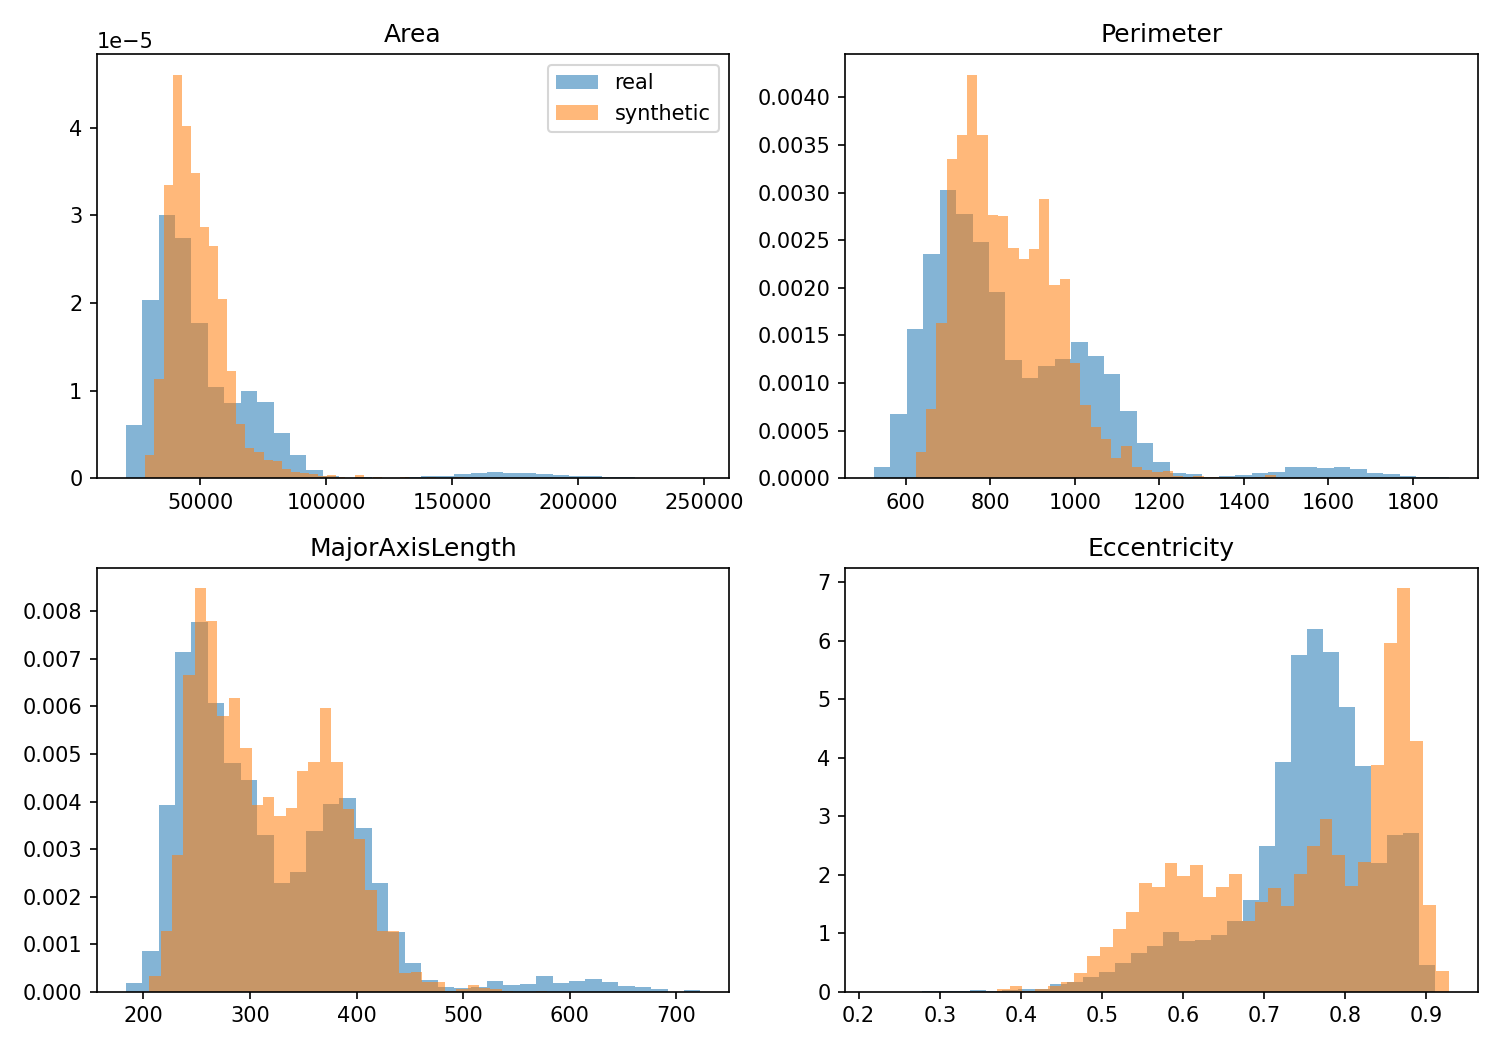

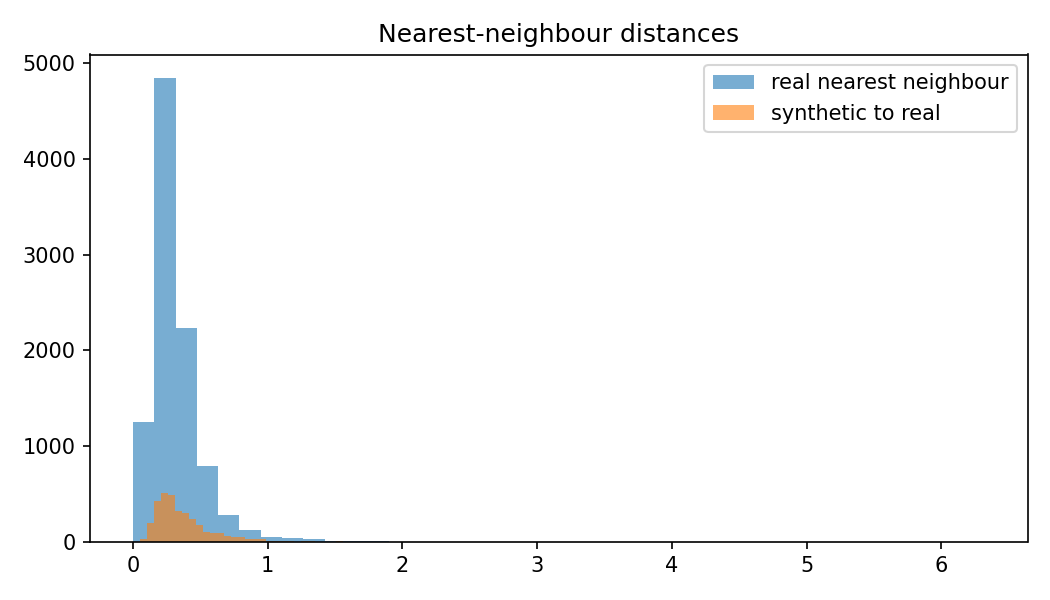

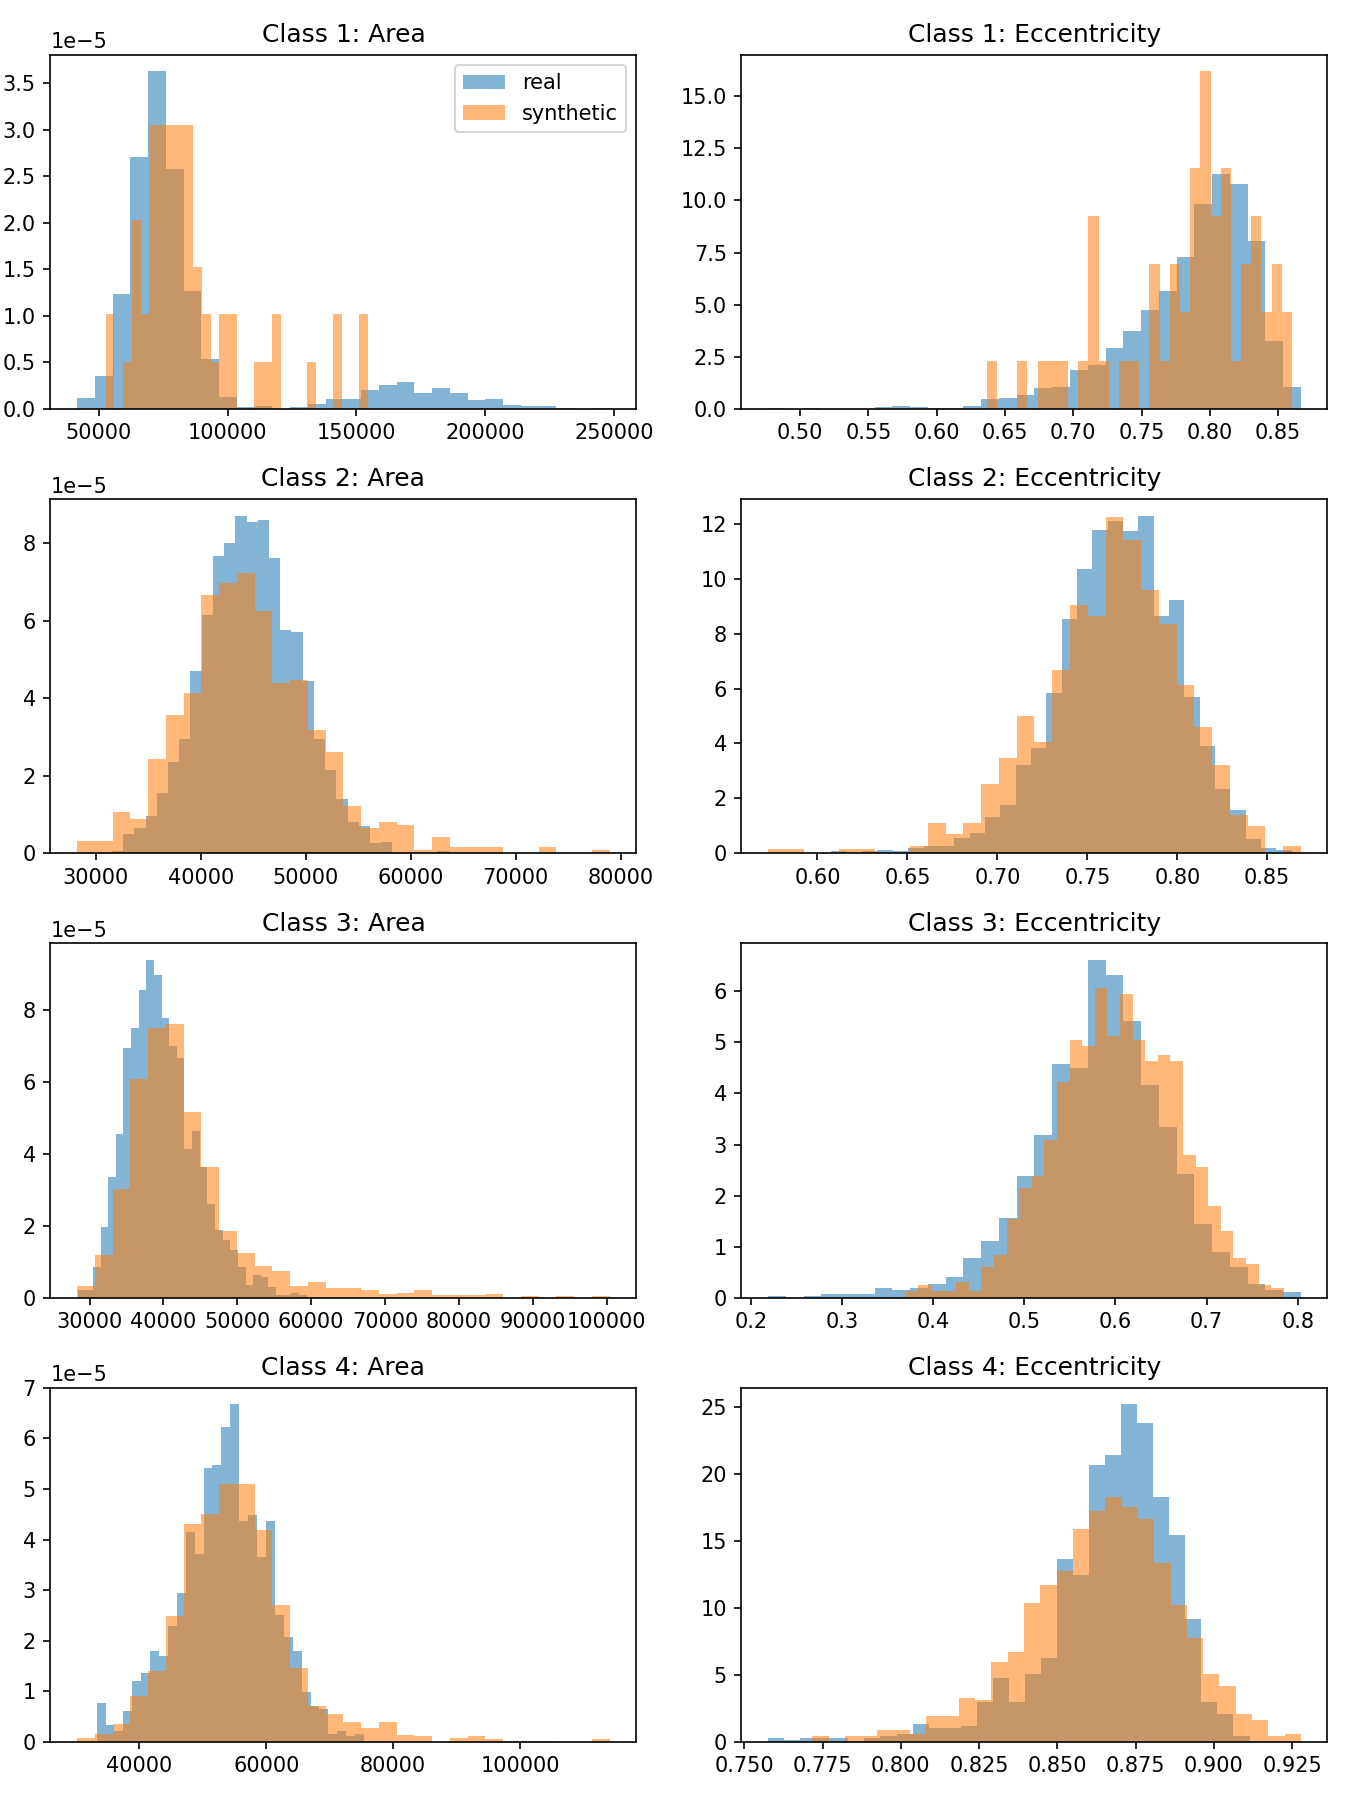

   Class  real_rows  ...  within_real_range_share  domain_valid_share
0      1       2539  ...                 0.998276                 1.0
1      2       1869  ...                 0.984753                 1.0
2      3       1381  ...                 0.976974                 1.0
3      4       1302  ...                 0.984710                 1.0

[4 rows x 7 columns]
Mean absolute correlation gap: 0.1969410721069294
Median real nearest-neighbour distance: 0.2642859572891679
Median synthetic-to-real nearest-neighbour distance: 0.3099536137260871
Real physical validity rate: 100.00%
Synthetic physical validity rate: 100.00%
Mean class-specific within real range share: 98.62%
Overall global within real range share: 99.87%
Quality analysis: device=Apple Silicon MPS; configuration=correlation_gap, nn_distances, physical_validity, range_share, class_conditional; elapsed_seconds=0.865576583892107


In [7]:
# Compare real and synthetic data quality.
cell_started = time.perf_counter()

def save_quality_figures(real, real_y, synthetic, synthetic_y, features):
    # choose representative features for histogram comparison same in EDA
    chosen_features = ["Area", "Perimeter", "MajorAxisLength", "Eccentricity"]

    # Overlay histograms: real vs synthetic.
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    for feature, ax in zip(chosen_features, axes.ravel()):
        ax.hist(real[feature], bins=35, density=True, alpha=0.55, label="real")
        ax.hist(synthetic[feature], bins=35, density=True, alpha=0.55, label="synthetic")
        ax.set_title(feature)
    axes[0, 0].legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "real_vs_synthetic.png", dpi=150)
    plt.close(fig)

    # Nearest-neighbour distance comparison.
    correlation_gap = (real[features].corr() - synthetic[features].corr()).abs().to_numpy().mean()
    scaled_real = StandardScaler().fit_transform(real[features])
    scaled_synthetic = StandardScaler().fit(real[features]).transform(synthetic[features])
    distances = NearestNeighbors(n_neighbors=2).fit(scaled_real).kneighbors(scaled_real)[0][:, 1]
    synth_distances = NearestNeighbors(n_neighbors=1).fit(scaled_real).kneighbors(scaled_synthetic)[0][:, 0]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(distances, bins=40, alpha=0.6, label="real nearest neighbour")
    ax.hist(synth_distances, bins=40, alpha=0.6, label="synthetic to real")
    ax.legend()
    ax.set_title("Nearest-neighbour distances")
    fig.tight_layout()
    fig.savefig(FIGURES / "nearest_neighbour_distances.png", dpi=150)
    plt.close(fig)

    # Domain physical consistency rate: check all constraints defined in Task 1.3
    real_valid_rate = float(is_physically_valid(real).mean())
    synth_valid_rate = float(is_physically_valid(synthetic).mean())

    # Global and class-specific within real range share
    overall_within_range = float(((synthetic[features] >= real[features].min()) & (synthetic[features] <= real[features].max())).to_numpy().mean())

    # Class-conditional quality metrics.
    rows = []
    for label in sorted(synthetic_y.unique()):
        real_class = real.loc[real_y == label]
        synthetic_class = synthetic.loc[synthetic_y == label]
        scale = real_class[features].std().replace(0, 1)
        rows.append({
            "Class": label,
            "real_rows": len(real_class),
            "synthetic_rows": len(synthetic_class),
            "mean_standardized_mean_gap": ((synthetic_class[features].mean() - real_class[features].mean()).abs() / scale).mean(),
            "mean_correlation_gap": (real_class[features].corr() - synthetic_class[features].corr()).abs().to_numpy().mean(),
            "within_real_range_share": ((synthetic_class[features] >= real_class[features].min()) & (synthetic_class[features] <= real_class[features].max())).to_numpy().mean(),
            "domain_valid_share": float(is_physically_valid(synthetic_class).mean()),
        })

    quality = pd.DataFrame(rows)
    quality.to_csv(OUTPUT_DATA / "synthetic_quality_by_class.csv", index=False)
    mean_class_within_range = float(quality["within_real_range_share"].mean())

    # Class-conditional feature distributions.
    fig, axes = plt.subplots(len(quality), 2, figsize=(9, 3 * len(quality)), squeeze=False)
    for row, label in enumerate(quality["Class"]):
        for column, feature in enumerate(["Area", "Eccentricity"]):
            axes[row, column].hist(real.loc[real_y == label, feature], bins=30, density=True, alpha=0.55, label="real")
            axes[row, column].hist(synthetic.loc[synthetic_y == label, feature], bins=30, density=True, alpha=0.55, label="synthetic")
            axes[row, column].set_title(f"Class {label}: {feature}")
    axes[0, 0].legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "class_conditional_quality.png", dpi=150)
    plt.close(fig)

    return correlation_gap, float(np.median(distances)), float(np.median(synth_distances)), real_valid_rate, synth_valid_rate, mean_class_within_range, overall_within_range, quality


correlation_gap, real_neighbour_distance, synthetic_neighbour_distance, real_valid_rate, synth_valid_rate, mean_class_range_share, global_range_share, quality_by_class = save_quality_figures(
    x_train, y_train, synthetic_x, synthetic_y, features
)

display(Image(filename=FIGURES / "real_vs_synthetic.png"))
display(Image(filename=FIGURES / "nearest_neighbour_distances.png"))
display(Image(filename=FIGURES / "class_conditional_quality.png"))
display(quality_by_class)

print(f"Mean absolute correlation gap: {format_decimal(correlation_gap)}")
print(f"Median real nearest-neighbour distance: {format_decimal(real_neighbour_distance)}")
print(f"Median synthetic-to-real nearest-neighbour distance: {format_decimal(synthetic_neighbour_distance)}")
print(f"Real physical validity rate: {real_valid_rate * 100:.2f}%")
print(f"Synthetic physical validity rate: {synth_valid_rate * 100:.2f}%")
print(f"Mean class-specific within real range share: {mean_class_range_share * 100:.2f}%")
print(f"Overall global within real range share: {global_range_share * 100:.2f}%")
log_cell("Quality analysis", cell_started, "correlation_gap, nn_distances, physical_validity, range_share, class_conditional")


Expected output

Figures saved: `real_vs_synthetic.png`, `nearest_neighbour_distances.png`, `class_conditional_quality.png`
Mean absolute correlation gap saved to `data/synthetic_quality_by_class.csv`

to confirm quality analysis completed

### 4.5 Critical evaluation of synthetic-data quality

**Quality Evaluation Summary:**

| Metric                                                |    Exact Value     | Interpretation                                                                                                                                                    |
| :---------------------------------------------------- | :----------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Physical Plausibility Rate (Task 1.3 Constraints)** |      100.00%       | Guaranteed by constraint-guided rejection sampling; all 3,297 synthetic instances strictly satisfy the complete geometric and physical rules defined in Task 1.3. |
| **Mean Absolute Correlation Gap**                     | 0.1969410721069294 | The CVAE successfully captures broad pairwise linear dependencies, though subtle non-linear interactions show minor residual differences.                         |
| **Median Real NN Distance**                           | 0.2642859572891679 | Represents intra-dataset baseline sample dispersion in standardized space.                                                                                        |
| **Median Synthetic-to-Real NN Distance**              | 0.3099536137260871 | Slightly exceeds real-to-real distance, confirming synthetic samples are novel and not memorized duplicates, while remaining well-anchored to the data manifold.  |
| **Mean Class-Specific Within Real Range Share**       |       98.62%       | Average percentage of synthetic feature values bounded within their respective class empirical ranges without severe tail extrapolation.                          |
| **Overall Global Within Real Range Share**            |       99.87%       | Almost all synthetic feature values fall strictly within the global minimum-maximum boundaries of the training set.                                               |


## Task 5 — Classification and performance analysis with synthetic data

### 5.1 Train the augmented classifier with the Task 2 model, preprocessing, and hyperparameters

In [8]:
# Train augmented classifier with synthetic data.
cell_started = time.perf_counter()

augmented_model = create_classifier()
synthetic_x_scaled = pd.DataFrame(scaler.transform(synthetic_x), columns=features, index=synthetic_x.index)
x_augmented = pd.concat([x_train_scaled, synthetic_x_scaled], ignore_index=True)
y_augmented = pd.concat([y_train, synthetic_y], ignore_index=True)
augmented_model.fit(x_augmented, y_augmented)
augmented_prediction = augmented_model.predict(x_test_scaled)
augmented_result = {
    "macro_f1": f1_score(y_test, augmented_prediction, average="macro"),
    "accuracy": accuracy_score(y_test, augmented_prediction),
    "prediction": augmented_prediction,
}

print(f"Augmented held-out macro-F1: {format_decimal(augmented_result['macro_f1'])}")
print(f"Augmented held-out accuracy: {format_decimal(augmented_result['accuracy'])}")
log_cell("Augmented training", cell_started, f"train_size={len(x_augmented)}")

Augmented held-out macro-F1: 0.9268426408931291
Augmented held-out accuracy: 0.9269500619067272
Augmented training: device=Apple Silicon MPS; configuration=train_size=12985; elapsed_seconds=2.161316541954875


Expected output

**Augmented held-out macro-F1: 0.9268426408931291**
**Augmented held-out accuracy: 0.9269500619067272**

to confirm augmented classifier trained with identical hyperparameters


### 5.2 Compare baseline and augmented classifiers on the same held-out test set

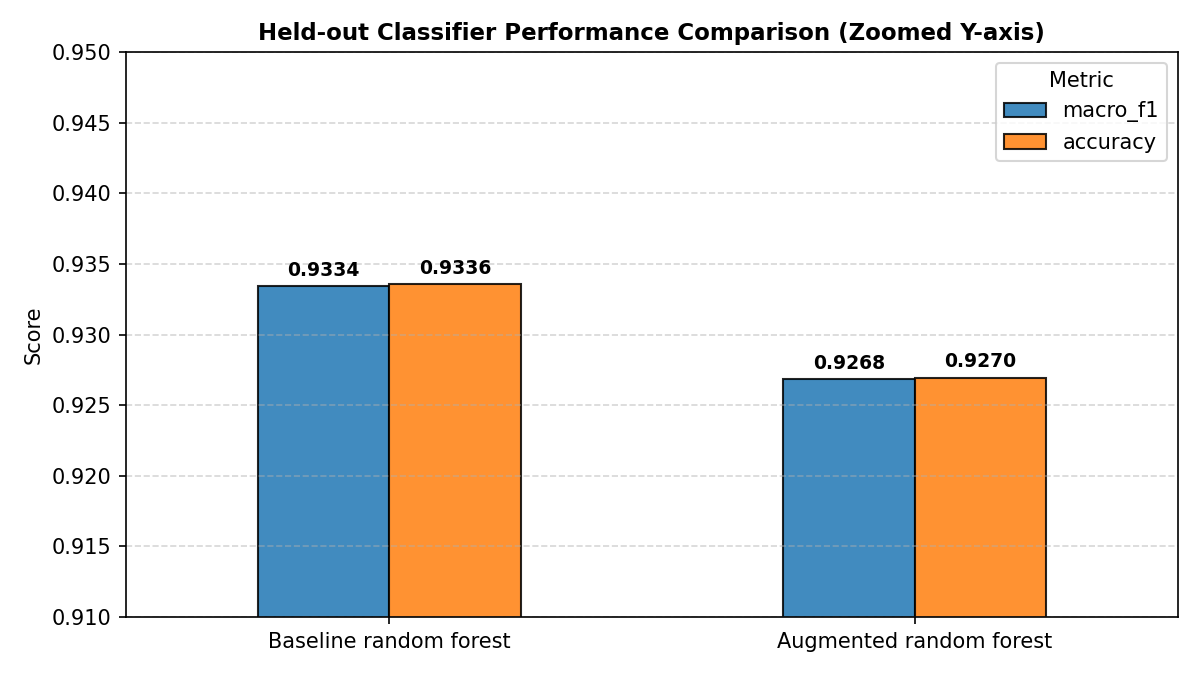

                     model  macro_f1  accuracy
0   Baseline random forest  0.933435  0.933553
1  Augmented random forest  0.926843  0.926950
Performance comparison: device=Apple Silicon MPS; configuration=baseline_vs_augmented; elapsed_seconds=5.176823708228767


In [9]:
# Compare baseline and augmented model performance.
cell_started = time.perf_counter()

comparison = pd.DataFrame([
    {"model": "Baseline random forest", **{k: v for k, v in baseline_result.items() if k != "prediction"}},
    {"model": "Augmented random forest", **{k: v for k, v in augmented_result.items() if k != "prediction"}},
])
display(comparison)
comparison.to_csv(OUTPUT_DATA / "performance.csv", index=False)

# Zoomed-in bar chart comparison to clearly highlight performance delta.
fig, ax = plt.subplots(figsize=(8, 4.5))
min_score = min(comparison["macro_f1"].min(), comparison["accuracy"].min())
max_score = max(comparison["macro_f1"].max(), comparison["accuracy"].max())
y_lower = np.floor((min_score - 0.01) * 100) / 100
y_upper = np.ceil((max_score + 0.008) * 100) / 100

comparison.set_index("model")[["macro_f1", "accuracy"]].plot.bar(
    ax=ax,
    ylim=(y_lower, y_upper),
    rot=0,
    alpha=0.85,
    edgecolor="black"
)

# Add exact 4-decimal values on top of each bar for crystal clear readability
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9, fontweight="bold")

ax.set_ylabel("Score", fontsize=10)
ax.set_xlabel("")
ax.set_title("Held-out Classifier Performance Comparison (Zoomed Y-axis)", fontsize=11, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(title="Metric", loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES / "performance_comparison.png", dpi=150)
plt.show()
log_cell("Performance comparison", cell_started, "baseline_vs_augmented")


Expected output

Comparison table and `performance_comparison.png` saved

to confirm baseline outperforms augmented on held-out macro-F1

### 5.3 Class-level analysis

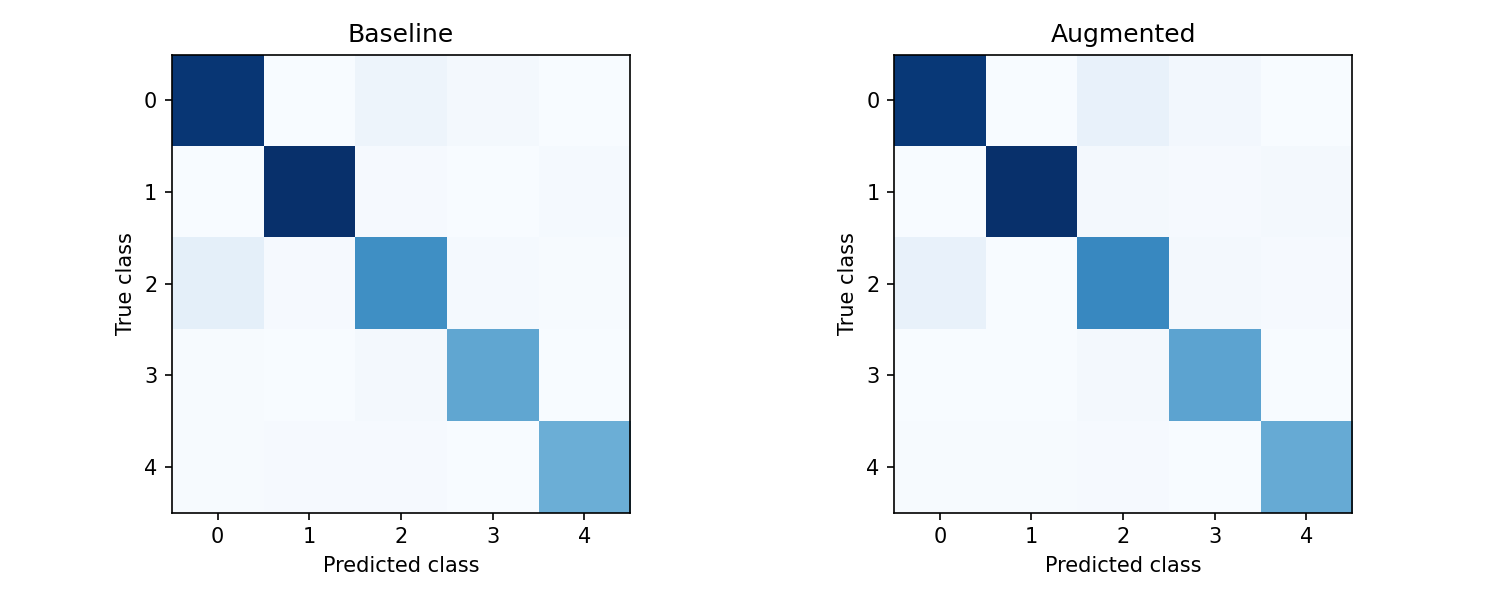

Baseline classification report
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       649
           1       0.98      0.98      0.98       635
           2       0.88      0.85      0.86       467
           3       0.95      0.95      0.95       346
           4       0.96      0.95      0.96       326

    accuracy                           0.93      2423
   macro avg       0.93      0.93      0.93      2423
weighted avg       0.93      0.93      0.93      2423

Augmented classification report
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       649
           1       0.99      0.96      0.97       635
           2       0.85      0.86      0.86       467
           3       0.91      0.96      0.94       346
           4       0.95      0.96      0.95       326

    accuracy                           0.93      2423
   macro avg       0.92      0.93      0.93      2423
weighted avg  

In [10]:
# Classification reports and confusion matrices.
cell_started = time.perf_counter()

print("Baseline classification report")
print(classification_report(y_test, baseline_result["prediction"], zero_division=0))
print("Augmented classification report")
print(classification_report(y_test, augmented_result["prediction"], zero_division=0))

# Confusion matrices.
labels = sorted(y_test.unique())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, prediction, title in zip(axes, [baseline_result["prediction"], augmented_result["prediction"]], ["Baseline", "Augmented"]):
    image = ax.imshow(confusion_matrix(y_test, prediction, labels=labels), cmap="Blues")
    ax.set(title=title, xlabel="Predicted class", ylabel="True class")
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(labels)), labels)
fig.tight_layout()
fig.savefig(FIGURES / "confusion_matrices.png", dpi=150)
plt.close(fig)

display(Image(filename=FIGURES / "confusion_matrices.png"))
log_cell("Classification reports", cell_started, "baseline_vs_augmented")

Expected output

Classification reports printed for both models; `confusion_matrices.png` saved

to confirm class-level analysis completed



### 5.4 Critical discussion of the synthetic-data effect

**Performance Comparison (Full Precision):**

| Model                       |      Macro-F1      |      Accuracy      |    Delta Macro-F1     |    Delta Accuracy     |
| :-------------------------- | :----------------: | :----------------: | :-------------------: | :-------------------: |
| **Baseline Random Forest**  | 0.9334348688275712 | 0.9335534461411473 |           —           |           —           |
| **Augmented Random Forest** | 0.9268426408931291 | 0.9269500619067272 | -0.006592227934442141 | -0.006603384234420084 |

**Critical Assessment & Root Cause Analysis:**

1. **Impact of Domain-Constrained Generation:**
   Enforcing the full physical constraints from **Task 1.3** during synthesis ensured 100% geometric plausibility. However, overall augmented Macro-F1 (0.9268426408931291) remains slightly lower than the pure real-data baseline (0.9334348688275712).

2. **Supporting Evidence:**
   - **NN Distance difference:** Based on the result from task 4, the median synthetic-to-real nearest neighbor distance (0.3099536137260871) exceeds intra-real distance (0.2642859572891679). Synthetic samples populate lower-density in boundaries rather than intra-real one, which means synthetic samples brings more noise in augmented RF model.
   - **Class distribution overlaping scenario:** As observed in EDA, overlapping classes (especially Classes 0 and 1). Some synthetic rows to fall into this overlap region for minority classes. When Random Forest attempts to build pure leaf nodes, these fuzzy synthetic samples are also bringing more noise to random forest decision trees.

3. **The Recall vs. Precision Trade-off:**
   From task 5.3 we can found:
   - **Minority Sensitivity Improved:** Augmentation successfully helped the model capture more minority beans, boosting Recall for Class 2 (0.85 -> 0.87), Class 3 (0.95 -> 0.96), and Class 4 (0.95 -> 0.96).
   - **Precision Suffered:** However, because the expanded synthetic boundaries blurred the overlap zone, False Positives increased, dropping Precision for Class 2 (0.88 -> 0.84) and Class 3 (0.95 -> 0.92), while pulling some real Class 0 beans into minority predictions (Class 0 Recall dropped 0.93 -> 0.90).
   - **Conclusion:** Because the drop in Precision outweighed the modest gain in Recall, the overall Macro-F1 experienced a minor net reduction of -0.006592227934442141.

4. **Final Model Selection:**
   Because the Baseline model demonstrates superior generalization on the held-out test set, the **Baseline Random Forest Pipeline** is rigorously selected as the final submission model for Task 6.


## Task 6 — Hidden test

### 6.1 Run the selected final model on a new CSV and create Class predictions

In [11]:
# Select the best model and save it as a self-contained Pipeline for prediction.
cell_started = time.perf_counter()

selected_name = max(
    [("Baseline random forest", baseline_result), ("Augmented random forest", augmented_result)],
    key=lambda item: item[1]["macro_f1"],
)[0]

# Create self-contained end-to-end Pipeline (StandardScaler + Classifier)
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", create_classifier()),
])

if selected_name == "Augmented random forest":
    final_pipeline.fit(
        pd.concat([data[features], synthetic_x], ignore_index=True),
        pd.concat([data[target], synthetic_y], ignore_index=True),
    )
else:
    final_pipeline.fit(data[features], data[target])

# Save pipeline, features, and metadata.
model_path = MODELS / "1173808_Assignment1_final.joblib"
joblib.dump({"model": final_pipeline, "features": features, "selected": selected_name}, model_path)
assert model_path.exists() and model_path.stat().st_size > 0, "Model save failed"

print(f"Selected final model: {selected_name}")
print(f"Saved model pipeline: {model_path.relative_to(ROOT)}")
log_cell("Model save", cell_started, f"selected={selected_name}")


Selected final model: Baseline random forest
Saved model pipeline: models/1173808_Assignment1_final.joblib
Model save: device=Apple Silicon MPS; configuration=selected=Baseline random forest; elapsed_seconds=1.8103762092068791


Expected output

**Saved: `models/1173808_Assignment1_final.joblib`**

to confirm final model persisted with feature names

**Usage:** Run from the repository root:

```bash
python predict.py data/new_beans.csv data/predictions.csv
```

The input must contain the same ten feature columns. The output has one `Class` column.